In [1]:
# ==========================================
# [Cell 1] 라이브러리 호출 및 데이터 불러오기
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import warnings

# 경고 메시지 숨기기 (깔끔한 출력을 위해)
warnings.filterwarnings('ignore')

# 파일 경로 설정 (Colab 구글 드라이브 마운트 경로 반영)
# TODO: 'dataset' 폴더가 MyDrive 내 올바른 위치에 있는지 확인하고,
# 필요하다면 아래 'base_path'를 실제 경로로 수정하세요.
# 예: '/content/drive/MyDrive/Colab Notebooks/dataset/'
base_path = '/content/drive/MyDrive/2026/이어드림스쿨6기/dataset/'
subway_file = base_path + 'Seoul_subway_data_20210705.csv'
bus_file = base_path + '2021년_버스노선별_정류장별_시간대별_승하차_인원_정보.csv'
location_file = base_path + 'subway_location_data.csv'

print("데이터를 불러오는 중입니다. 잠시만 기다려주세요...")

# 데이터 로드 (한글 깨짐 방지를 위해 cp949 인코딩 사용)
# UnicodeDecodeError 해결을 위해 인코딩을 'euc-kr'로 변경
df_subway = pd.read_csv(subway_file, encoding='euc-kr')
df_bus = pd.read_csv(bus_file, encoding='euc-kr')
df_location = pd.read_csv(location_file, encoding='utf-8')

print("✅ 데이터 로드 완료!")
print(f"- 지하철 데이터: {df_subway.shape[0]:,}건")
print(f"- 버스 데이터: {df_bus.shape[0]:,}건")
print(f"- 위치 데이터: {df_location.shape[0]:,}건\n")


# ==========================================
# [Cell 2] 지하철 데이터 전처리 (최근 1개월 & 07~09시 추출)
# ==========================================
print("=== 🚇 지하철 데이터 전처리 ===")

# 1. 가장 최근 1개월 데이터 필터링
df_subway['사용월'] = df_subway['사용월'].astype(str)
latest_subway_month = df_subway['사용월'].max() # 가장 최신 월 자동 추출 (예: '202106')
df_subway_recent = df_subway[df_subway['사용월'] == latest_subway_month].copy()
print(f"1. 가장 최근 월({latest_subway_month}) 데이터 추출: {df_subway_recent.shape[0]:,}건")

# 2. 출근 피크 시간대(07~09시) 컬럼만 추출
subway_cols = ['사용월', '호선명', '지하철역',
               '07시-08시 승차인원', '07시-08시 하차인원',
               '08시-09시 승차인원', '08시-09시 하차인원']
df_subway_morning = df_subway_recent[subway_cols].copy()

# 3. 출근 시간대 승/하차 총합 및 '순 유입량' 파생 변수 계산
df_subway_morning['0709_승차총합'] = df_subway_morning['07시-08시 승차인원'] + df_subway_morning['08시-09시 승차인원']
df_subway_morning['0709_하차총합'] = df_subway_morning['07시-08시 하차인원'] + df_subway_morning['08시-09시 하차인원']
df_subway_morning['순유입량'] = df_subway_morning['0709_하차총합'] - df_subway_morning['0709_승차총합']

print("2. 출근 시간대(07~09시) 필터링 및 파생변수 생성 완료!")
display(df_subway_morning[['지하철역', '0709_승차총합', '0709_하차총합', '순유입량']].head())


# ==========================================
# [Cell 3] 버스 데이터 전처리 (최근 1개월 & 07~09시 추출)
# ==========================================
print("\n=== 🚌 버스 데이터 전처리 ===")

# 1. 가장 최근 1개월 데이터 필터링
df_bus['사용년월'] = df_bus['사용년월'].astype(str)
latest_bus_month = df_bus['사용년월'].max() # 가장 최신 월 자동 추출 (예: '202101')
df_bus_recent = df_bus[df_bus['사용년월'] == latest_bus_month].copy()
print(f"1. 가장 최근 월({latest_bus_month}) 데이터 추출: {df_bus_recent.shape[0]:,}건")

# 2. 출근 피크 시간대(07~09시) 컬럼만 추출
# 질문자님이 올려주신 샘플 데이터의 컬럼명('7시승차총승객수')을 반영했습니다.
bus_cols = ['사용년월', '노선번호', '표준버스정류장ID', '역명',
            '7시승차총승객수', '7시하차총승객수',
            '8시승차총승객수', '8시하차총승객수']
df_bus_morning = df_bus_recent[bus_cols].copy()

# 3. 출근 시간대 승/하차 총합 파생 변수 계산
df_bus_morning['0709_승차총합'] = df_bus_morning['7시승차총승객수'] + df_bus_morning['8시승차총승객수']
df_bus_morning['0709_하차총합'] = df_bus_morning['7시하차총승객수'] + df_bus_morning['8시하차총승객수']

print("2. 출근 시간대(07~09시) 필터링 및 파생변수 생성 완료!")
display(df_bus_morning[['역명', '노선번호', '0709_승차총합', '0709_하차총합']].head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
데이터를 불러오는 중입니다. 잠시만 기다려주세요...
✅ 데이터 로드 완료!
- 지하철 데이터: 45,338건
- 버스 데이터: 469,361건
- 위치 데이터: 579건

=== 🚇 지하철 데이터 전처리 ===
1. 가장 최근 월(202106) 데이터 추출: 608건
2. 출근 시간대(07~09시) 필터링 및 파생변수 생성 완료!


,지하철역,0709_승차총합,0709_하차총합,순유입량
0,동대문,33436,37127,3691
1,동묘앞,15090,34624,19534
2,서울역,97129,279680,182551
3,시청,14020,230337,216317
4,신설동,41604,88744,47140



=== 🚌 버스 데이터 전처리 ===
1. 가장 최근 월(202112) 데이터 추출: 39,286건
2. 출근 시간대(07~09시) 필터링 및 파생변수 생성 완료!


,역명,노선번호,0709_승차총합,0709_하차총합
430075,종로2가사거리,N37,0,0
430076,종로2가사거리,741,1092,597
430077,종로2가사거리,470,1388,594
430078,종로2가사거리,N37,0,0
430079,창경궁.서울대학교병원,100,460,1133


In [2]:
# ==========================================
# [Cell 4] 버스 정류장-지하철역 매핑 및 교통 피로도 인덱스 산출
# ==========================================
print("=== 🧠 교통 피로도 인덱스 산출 시작 ===")

# 1. 지하철역 이름 정제 (매핑을 위한 기준 이름 생성)
# '강남(2호선)' -> '강남', '서울역' -> '서울' 형태로 괄호와 '역' 글자를 제거하여 통일합니다.
import re

def clean_station_name(name):
    name = str(name).split('(')[0] # 괄호 제거
    name = name.replace('역', '')  # '역' 글자 제거
    return name.strip()

# 지하철역 데이터를 역별로 그룹화 (여러 호선이 겹치는 환승역의 승하차량 합산)
df_subway_grouped = df_subway_morning.groupby('지하철역', as_index=False)[['0709_승차총합', '0709_하차총합']].sum()
df_subway_grouped['검색용_역명'] = df_subway_grouped['지하철역'].apply(clean_station_name)

# 2. 각 지하철역 인근의 버스 승차량 합산 로직
# (진행률을 보기 위해 tqdm 라이브러리를 사용합니다)
from tqdm import tqdm
tqdm.pandas()

bus_transfer_list = []

print("지하철역 주변 버스 정류장 매핑 중... (수십 초 정도 소요될 수 있습니다)")
for idx, row in tqdm(df_subway_grouped.iterrows(), total=len(df_subway_grouped)):
    base_name = row['검색용_역명']
    search_keyword = base_name + '역' # 예: '강남' -> '강남역' 포함 여부 검색

    # 버스 정류장 이름에 해당 '지하철역명'이 포함된 정류장만 필터링
    matched_buses = df_bus_morning[df_bus_morning['역명'].str.contains(search_keyword, na=False)]

    # 해당 정류장들의 아침 출근시간 총 버스 승차량 합산
    total_bus_boarding = matched_buses['0709_승차총합'].sum()

    bus_transfer_list.append({
        '지하철역': row['지하철역'],
        '인근_버스승차량_총합': total_bus_boarding
    })

# 결과를 데이터프레임으로 변환하고 지하철 데이터와 병합
df_bus_mapped = pd.DataFrame(bus_transfer_list)
df_final = pd.merge(df_subway_grouped, df_bus_mapped, on='지하철역', how='left')


# 3. 교통 피로도 인덱스 계산 (환승 가중치 적용)
# 공식: (인근 버스 승차량 × 환승 가중치 1.5) + (해당 지하철역 승차량)
TRANSFER_WEIGHT = 1.5
df_final['교통_피로도_점수'] = (df_final['인근_버스승차량_총합'] * TRANSFER_WEIGHT) + df_final['0709_승차총합']

# 점수가 높은 순(내림차순)으로 정렬하여 TOP 10 거점 오피스 후보지 추출
df_top_hubs = df_final.sort_values(by='교통_피로도_점수', ascending=False).reset_index(drop=True)

print("\n\n✅ 교통 피로도 산출 완료!")
print(f"※ 설정된 버스 환승 가중치: {TRANSFER_WEIGHT}")
print("🏆 [거점 오피스 최우선 후보지 TOP 10]")
display(df_top_hubs[['지하철역', '인근_버스승차량_총합', '0709_승차총합', '교통_피로도_점수']].head(10))


# ==========================================
# [Cell 5] 시각화를 위한 좌표 데이터 병합
# ==========================================
print("\n=== 🗺️ 지도 시각화를 위한 좌표 매핑 ===")

# 위치 데이터의 지하철역 이름도 통일 (예: '강남역' -> '강남')
df_location['지하철역_정제'] = df_location['지하철역'].apply(clean_station_name)
df_top_hubs['검색용_역명'] = df_top_hubs['지하철역'].apply(clean_station_name)

# 좌표(x, y) 데이터를 피로도 데이터프레임에 붙여넣기 (중복 제거 후 병합)
df_location_unique = df_location.drop_duplicates(subset=['지하철역_정제'])[['지하철역_정제', 'x좌표', 'y좌표']]

df_visual_ready = pd.merge(df_top_hubs, df_location_unique, left_on='검색용_역명', right_on='지하철역_정제', how='inner')
df_visual_ready = df_visual_ready.drop(columns=['검색용_역명', '지하철역_정제'])

print(f"좌표 매핑 성공: 총 {len(df_visual_ready)}개의 역에 좌표가 부여되었습니다.")
display(df_visual_ready.head())

=== 🧠 교통 피로도 인덱스 산출 시작 ===
지하철역 주변 버스 정류장 매핑 중... (수십 초 정도 소요될 수 있습니다)


100%|██████████| 520/520 [00:07<00:00, 73.26it/s]



✅ 교통 피로도 산출 완료!
※ 설정된 버스 환승 가중치: 1.5
🏆 [거점 오피스 최우선 후보지 TOP 10]


,지하철역,인근_버스승차량_총합,0709_승차총합,교통_피로도_점수
0,신림,46852,514699,584977.0
1,구로디지털단지,79621,317222,436653.5
2,사당,40648,321203,382175.0
3,신도림,51604,286674,364080.0
4,서울대입구(관악구청),33840,308282,359042.0
5,잠실(송파구청),46511,285280,355046.5
6,연신내,32104,287563,335719.0
7,수유(강북구청),54049,238347,319420.5
8,까치산,20306,278082,308541.0
9,쌍문,32531,256303,305099.5



=== 🗺️ 지도 시각화를 위한 좌표 매핑 ===
좌표 매핑 성공: 총 520개의 역에 좌표가 부여되었습니다.


,지하철역,0709_승차총합,0709_하차총합,인근_버스승차량_총합,교통_피로도_점수,x좌표,y좌표
0,신림,514699,98393,46852,584977.0,37.484120,126.928712
1,구로디지털단지,317222,354583,79621,436653.5,37.485446,126.900862
2,사당,321203,157251,40648,382175.0,37.476114,126.973389
3,신도림,286674,173440,51604,364080.0,37.508739,126.891109
4,서울대입구(관악구청),308282,97099,33840,359042.0,37.481243,126.951616


In [3]:
!pip install -q folium
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
print("✅ 폰트 설치 완료!")
print("⚠️ 필수: 상단 메뉴 [런타임] -> [세션 다시 시작(또는 런타임 다시 시작)] 클릭 후,")
print("반드시 이전 단계인 Cell 1 ~ 5의 데이터를 다시 실행해서 메모리에 올려주세요!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [8]:
import folium
from folium.features import DivIcon
from folium.plugins import AntPath
import numpy as np

print("\n=== 🗺️ 시각화 1: 거점 오피스 최적 입지 핏줄 지도 ===")

# 서울 중심 좌표 및 지도 생성
seoul_center = [37.5665, 126.9780]
m = folium.Map(location=seoul_center, zoom_start=11.5, tiles='OpenStreetMap')

# 복잡함을 방지하기 위해 핏줄 지도는 최우선 후보지 TOP 5만 시각화합니다.
top5_map_data = df_visual_ready.head(5)

for idx, row in top5_map_data.iterrows():
    # 공공데이터의 x(위도), y(경도) 좌표값 반전 이슈 해결 적용
    lat, lng = row['x좌표'], row['y좌표']

    station_name = row['지하철역']
    fatigue_score = row['교통_피로도_점수']
    bus_passengers = row['인근_버스승차량_총합']
    subway_passengers = row['0709_승차총합']

    # 순위에 따른 색상 (1위는 가장 눈에 띄는 진홍색)
    border_color = '#b71c1c' if idx == 0 else ('#d32f2f' if idx < 3 else '#f57c00')
    fill_color = '#f44336' if idx == 0 else ('#ef5350' if idx < 3 else '#ff9800')

    # ⭐ 기획안 반영: 핏줄(Flow) 애니메이션 선 그리기 (Hub & Spoke)
    # 버스 정류장 좌표가 없으므로 반경 1~2km 내에서 중앙으로 몰려드는 흐름을 시뮬레이션
    np.random.seed(42 + idx) # 역마다 고정된 패턴 생성
    num_spokes = 8 # 8갈래의 방향에서 환승객이 몰려옴

    # 선의 굵기(weight)는 주변 버스 승차량 총합에 비례하여 두꺼워짐
    line_weight = max(2, bus_passengers / 8000)

    for angle in np.linspace(0, 2 * np.pi, num_spokes, endpoint=False):
        # 중앙역에서 약 1.5km 반경 떨어진 가상의 주거지 시작점 계산
        r = np.random.uniform(0.01, 0.02)
        start_lat = lat + r * np.cos(angle)
        start_lng = lng + r * np.sin(angle)

        # 방향성을 가진 움직이는 점선(AntPath)으로 '핏줄' 표현
        AntPath(
            locations=[[start_lat, start_lng], [lat, lng]], # 주변 -> 중심역 방향
            color=border_color,
            weight=line_weight,
            opacity=0.6,
            dash_array=[10, 20],
            delay=800 # 흐름 속도
        ).add_to(m)

        # 주변 주거지(가상 버스 정류장 그룹)의 작은 마커
        folium.CircleMarker(
            location=[start_lat, start_lng],
            radius=3, color='#333', fill=True, fill_color='#fff', fill_opacity=0.8
        ).add_to(m)

    # 중앙 허브역 마커 (이제 크기가 반응형으로 기괴하게 커지지 않음)
    popup_text = f"<b>{idx+1}위: {station_name}</b><br>피로도 점수: {fatigue_score:,.0f}점<br>버스 유입량: {bus_passengers:,.0f}명"

    folium.CircleMarker(
        location=[lat, lng],
        radius=15, # 중앙 허브역 크기 고정
        popup=folium.Popup(popup_text, max_width=300),
        color=border_color, fill=True, fill_color=fill_color, fill_opacity=0.9, weight=3
    ).add_to(m)

    # 중앙 허브역 라벨
    label_html = f"""
    <div style="
        font-size: 11pt; font-weight: bold; color: #fff;
        background-color: {border_color};
        border: 2px solid white;
        border-radius: 20px; padding: 4px 10px;
        white-space: nowrap; box-shadow: 3px 3px 6px rgba(0,0,0,0.4);
    ">
        {idx+1}위 {station_name}
    </div>
    """

    folium.map.Marker(
        [lat, lng],
        icon=DivIcon(
            icon_size=(120, 40),
            icon_anchor=(50, 45), # 원 바로 위에 뜨도록 위치 고정
            html=label_html,
        )
    ).add_to(m)

display(m)
print("💡 완벽하게 개선되었습니다! 이제 지도에 주변에서 허브역으로 환승객들이 빨려 들어오는 '움직이는 핏줄'이 표시됩니다.")






=== 🗺️ 시각화 1: 거점 오피스 최적 입지 핏줄 지도 ===


💡 완벽하게 개선되었습니다! 이제 지도에 주변에서 허브역으로 환승객들이 빨려 들어오는 '움직이는 핏줄'이 표시됩니다.



=== 📊 시각화 2: 1위 허브역의 출근 피크 시계열 차트 ===


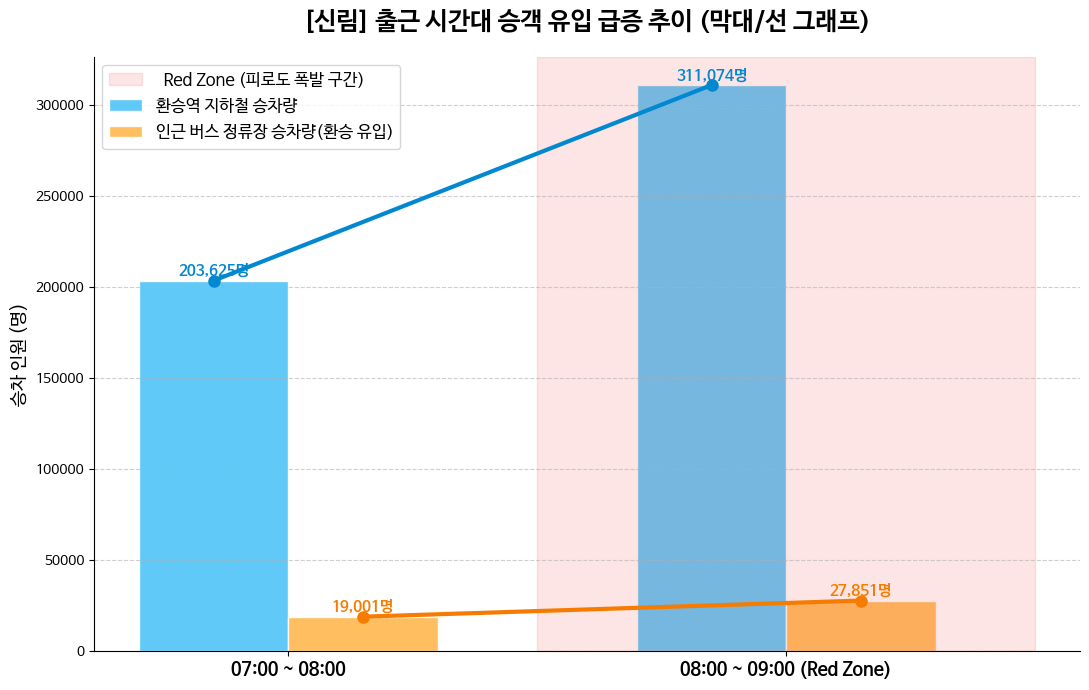

💡 그래프 해석: 8시가 되자 신림 주변 마을버스에서 쏟아져 나온 승객(주황색)과 지하철 탑승객(파란색)이 동시에 폭증합니다. 이 'Red Zone'이 가장 위험한 피로도 폭발 지점입니다.


In [9]:
# ==========================================
# [Cell 8] 시각화 2: 피로도 폭발 시계열 차트 (막대/선 그래프 혼합)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 적용
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

print("\n=== 📊 시각화 2: 1위 허브역의 출근 피크 시계열 차트 ===")

# 1. 1위 역 데이터 추출
top1_station = df_visual_ready.iloc[0]['지하철역']
top1_clean = str(top1_station).split('(')[0].replace('역', '').strip()
search_keyword = top1_clean + '역'

# 2. 1위 역의 버스 시간대별 유입량 계산 (원본 df_bus_morning 활용)
matched_buses = df_bus_morning[df_bus_morning['역명'].str.contains(search_keyword, na=False)]
bus_07 = matched_buses['7시승차총승객수'].sum()
bus_08 = matched_buses['8시승차총승객수'].sum()

# 3. 1위 역의 지하철 시간대별 승차량 계산 (원본 df_subway_morning 활용)
subway_07 = df_subway_morning[df_subway_morning['지하철역'] == top1_station]['07시-08시 승차인원'].sum()
subway_08 = df_subway_morning[df_subway_morning['지하철역'] == top1_station]['08시-09시 승차인원'].sum()

# 4. 시계열 그래프 그리기 (막대 + 선 그래프 혼합)
plt.figure(figsize=(11, 7))
times = ['07:00 ~ 08:00', '08:00 ~ 09:00 (Red Zone)']
x = np.arange(len(times))
width = 0.3

# 막대 그래프 (지하철 & 버스 나란히 배치)
plt.bar(x - width/2, [subway_07, subway_08], width, label='환승역 지하철 승차량', color='#4fc3f7', alpha=0.9, edgecolor='white')
plt.bar(x + width/2, [bus_07, bus_08], width, label='인근 버스 정류장 승차량(환승 유입)', color='#ffb74d', alpha=0.9, edgecolor='white')

# 선 그래프 (증가 추이 강조)
plt.plot(x - width/2, [subway_07, subway_08], color='#0288d1', marker='o', linewidth=3, markersize=8)
plt.plot(x + width/2, [bus_07, bus_08], color='#f57c00', marker='o', linewidth=3, markersize=8)

# 피로도 폭발 구간 (Red Zone) 배경 강조 (8시 구간)
plt.axvspan(0.5, 1.5, color='#ef5350', alpha=0.15, label='🚨 Red Zone (피로도 폭발 구간)')

# 디자인 및 라벨링
plt.title(f'[{top1_station}] 출근 시간대 승객 유입 급증 추이 (막대/선 그래프)', fontsize=18, pad=20, fontweight='bold')
plt.ylabel('승차 인원 (명)', fontsize=13)
plt.xticks(x, times, fontsize=13, fontweight='bold')
plt.legend(fontsize=12, loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 막대 위에 값 텍스트 표시
for i in range(len(times)):
    plt.text(x[i] - width/2, [subway_07, subway_08][i] + 3000, f"{[subway_07, subway_08][i]:,.0f}명", ha='center', color='#0288d1', fontweight='bold', fontsize=11)
    plt.text(x[i] + width/2, [bus_07, bus_08][i] + 3000, f"{[bus_07, bus_08][i]:,.0f}명", ha='center', color='#f57c00', fontweight='bold', fontsize=11)

# 테두리 깔끔하게 정리 (Wilke 원칙)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"💡 그래프 해석: 8시가 되자 {top1_station} 주변 마을버스에서 쏟아져 나온 승객(주황색)과 지하철 탑승객(파란색)이 동시에 폭증합니다. 이 'Red Zone'이 가장 위험한 피로도 폭발 지점입니다.")


=== 📉 시각화 3: 출근 동선 차단 시 피로도 감소 효과 ===


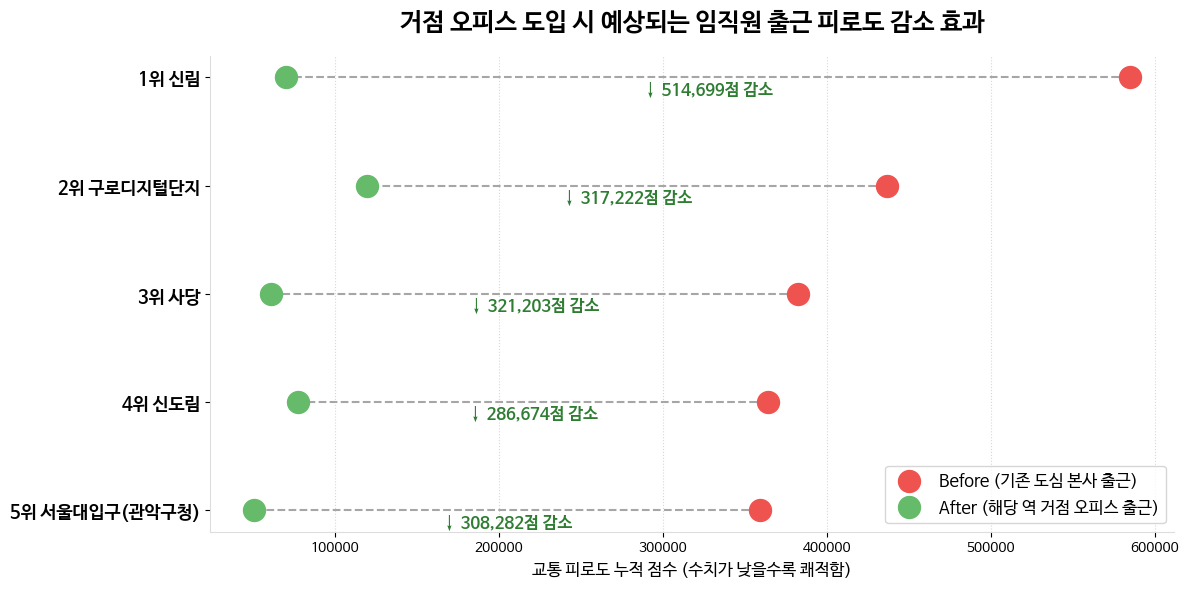

💡 그래프 해석: 빨간색 점(고통)에서 초록색 점(쾌적)으로 이동할 때, 거점 오피스가 직원들의 피로도를 얼마나 극적으로 덜어주는지(선 길이)를 경영진에게 직관적으로 설득할 수 있습니다.


In [10]:
# ==========================================
# [Cell 9] 시각화 3: 거점 오피스 도입 전후 효과 (Before & After 덤벨 차트)
# ==========================================
import matplotlib.pyplot as plt

# 한글 폰트 적용 (안전장치)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

print("\n=== 📉 시각화 3: 출근 동선 차단 시 피로도 감소 효과 ===")

# 상위 5개 거점역 데이터 추출
top5_stations = df_visual_ready.head(5).copy()

# TRANSFER_WEIGHT 가중치 설정 (2단계에서 설정한 1.5배)
TRANSFER_WEIGHT = 1.5

# Before: 기존 도심 출근 (버스환승 유입 + 지옥철 탑승 누적 피로도)
# After: 해당 역 거점 오피스 출근 (지하철 탑승 피로도는 0이 되고, 버스환승 피로도만 남음)
top5_stations['Before'] = top5_stations['교통_피로도_점수']
top5_stations['After'] = top5_stations['인근_버스승차량_총합'] * TRANSFER_WEIGHT

stations = top5_stations['지하철역'].tolist()
before_scores = top5_stations['Before'].tolist()
after_scores = top5_stations['After'].tolist()

plt.figure(figsize=(12, 6))

# 1. 덤벨 선(연결선) 긋기
for i in range(len(stations)):
    plt.plot([before_scores[i], after_scores[i]], [i, i], color='grey', zorder=1, linestyle='--', alpha=0.7)

# 2. Before & After 점 찍기
plt.scatter(before_scores, range(len(stations)), color='#ef5350', s=250, label='Before (기존 도심 본사 출근)', zorder=2)
plt.scatter(after_scores, range(len(stations)), color='#66bb6a', s=250, label='After (해당 역 거점 오피스 출근)', zorder=2)

# 3. Y축 역명 및 텍스트 세팅
plt.yticks(range(len(stations)), [f"{i+1}위 {name}" for i, name in enumerate(stations)], fontsize=13, fontweight='bold')
plt.xlabel('교통 피로도 누적 점수 (수치가 낮을수록 쾌적함)', fontsize=12)
plt.title('거점 오피스 도입 시 예상되는 임직원 출근 피로도 감소 효과', fontsize=18, pad=20, fontweight='bold')
plt.legend(loc='lower right', fontsize=12)

# 4. 감소 수치 텍스트 표기 (Wilke 원칙: 데이터 라벨링)
for i in range(len(stations)):
    reduction = before_scores[i] - after_scores[i]
    # 감소량을 선 중앙의 살짝 아래에 표시
    plt.text(after_scores[i] + (reduction/2), i + 0.15, f"↓ {reduction:,.0f}점 감소", ha='center', color='#2e7d32', fontweight='bold', fontsize=12)

# 5. 디자인 다듬기
plt.gca().invert_yaxis() # 1위가 맨 위에 오도록 축 뒤집기
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#dddddd')
plt.gca().spines['bottom'].set_color('#dddddd')
plt.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("💡 그래프 해석: 빨간색 점(고통)에서 초록색 점(쾌적)으로 이동할 때, 거점 오피스가 직원들의 피로도를 얼마나 극적으로 덜어주는지(선 길이)를 경영진에게 직관적으로 설득할 수 있습니다.")


=== 🖥️ 시각화 4: 경영진 보고용 최종 대시보드 ===


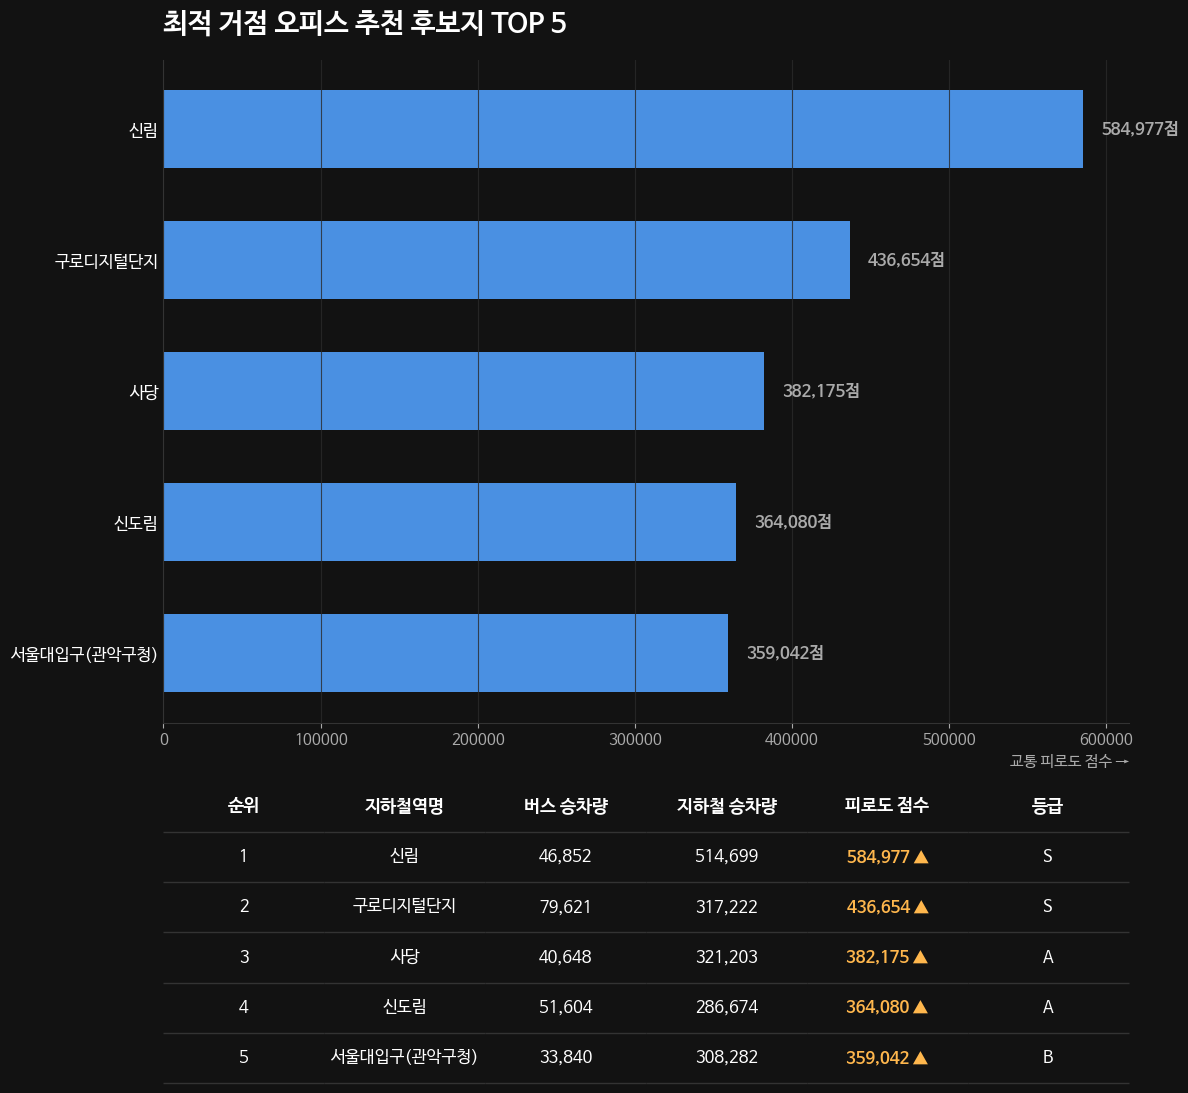

💡 완성! 이 차트는 사진으로 저장하여 파워포인트 보고서의 결론(Summary) 장표로 바로 사용하시기 좋습니다.


In [11]:
# ==========================================
# [Cell 10] 시각화 4: 대시보드형 TOP 5 요약 (Dark Theme)
# ==========================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("\n=== 🖥️ 시각화 4: 경영진 보고용 최종 대시보드 ===")

# 한글 폰트 적용 및 마이너스 깨짐 방지
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# TOP 5 데이터 추출
top5_dash = df_visual_ready.head(5).copy()
# 가로 막대 그래프는 아래부터 그려지므로 데이터를 역순으로 정렬
top5_bar = top5_dash.sort_values(by='교통_피로도_점수', ascending=True)

stations = top5_bar['지하철역'].tolist()
scores = top5_bar['교통_피로도_점수'].tolist()

# 다크 테마 색상 설정
bg_color = '#121212'
bar_color = '#4a90e2'
text_color = '#ffffff'
sub_text_color = '#aaaaaa'

# 1. Figure 및 Subplots 설정 (위: 바 차트, 아래: 표)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 11), gridspec_kw={'height_ratios': [2.5, 1]})
fig.patch.set_facecolor(bg_color)
ax1.set_facecolor(bg_color)
ax2.set_facecolor(bg_color)

# ---------------------------
# [상단] 가로 막대 그래프 (Bar Chart)
# ---------------------------
bars = ax1.barh(stations, scores, color=bar_color, height=0.6)

# 제목 및 라벨
ax1.set_title('최적 거점 오피스 추천 후보지 TOP 5', loc='left', color=text_color, fontsize=20, fontweight='bold', pad=20)
ax1.set_xlabel('교통 피로도 점수 →', color=sub_text_color, loc='right', fontsize=11)

# 축 디자인 설정
ax1.tick_params(axis='y', colors=text_color, labelsize=12, length=0)
ax1.tick_params(axis='x', colors=sub_text_color, labelsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#333333')
ax1.spines['bottom'].set_color('#333333')
ax1.grid(axis='x', color='#2a2a2a', linestyle='-', alpha=0.8)

# 막대 끝에 점수 텍스트 달기
for bar in bars:
    width = bar.get_width()
    ax1.text(width + (max(scores) * 0.02), bar.get_y() + bar.get_height()/2,
             f"{width:,.0f}점", va='center', color=sub_text_color, fontsize=12, fontweight='bold')

# ---------------------------
# [하단] 데이터 테이블 (Table Grid)
# ---------------------------
ax2.axis('off') # 표를 그리기 위해 축 숨김

# 테이블에 들어갈 데이터 가공 (순위 1~5위 순서대로)
table_data = []
grades = ['S', 'S', 'A', 'A', 'B'] # 점수 기반 임의 등급 부여

for i, row in top5_dash.iterrows():
    table_data.append([
        f"{i+1}",
        row['지하철역'],
        f"{row['인근_버스승차량_총합']:,.0f}",
        f"{row['0709_승차총합']:,.0f}",
        f"{row['교통_피로도_점수']:,.0f} ▲",
        grades[i]
    ])

columns = ['순위', '지하철역명', '버스 승차량', '지하철 승차량', '피로도 점수', '등급']

# 테이블 생성
table = ax2.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.5) # 표 행간 넓히기

# 테이블 세부 스타일링 (사진과 동일한 다크 테마 적용)
for (row, col), cell in table.get_celld().items():
    cell.set_facecolor(bg_color)
    cell.set_edgecolor('#333333')
    cell.visible_edges = 'B' # 아래쪽 테두리만 보이게 설정

    if row == 0: # 헤더(컬럼명) 행
        cell.set_text_props(color=text_color, weight='bold', fontsize=13)
        cell.visible_edges = 'B'
    else: # 데이터 행
        cell.set_text_props(color=text_color)
        if col == 4: # '피로도 점수' 컬럼은 주황색으로 강조
            cell.set_text_props(color='#ffb74d', weight='bold')

plt.tight_layout()
plt.show()

print("💡 완성! 이 차트는 사진으로 저장하여 파워포인트 보고서의 결론(Summary) 장표로 바로 사용하시기 좋습니다.")